# Line Detection Pipeline — Step-by-Step Visualization

This notebook walks through **every stage** of the skeleton-based wire detection algorithm used in CIRCUITRON.

**Algorithm overview:**
```
Raw Image → Binary Threshold → Skeletonize → Erase Text Regions
→ Dilate + Re-Skeletonize → Endpoint Detection → Global Merge
→ Multi-Head BFS Adjacency Graph → Remove Internal Edges
→ Dissolve Crossovers → Final Wire Connectivity Graph
```

**Test image:** `TestImages/crossover.png` — a hand-drawn circuit with wire crossovers.

In [1]:
import sys, os, math
import cv2
import numpy as np
from collections import deque
from itertools import combinations
from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte

# Add project root so we can import YOLO detector
sys.path.insert(0, "/Users/mac/Downloads/ cktnfromdrive")

# Import pipeline functions FIRST (pipeline.py sets matplotlib backend to Agg)
from test.pipeline import (
    _parse_yolo_text, _yolo_to_xyxy,
    _endpoint_for_class1_single,
    _skeleton_intersections_with_bbox_border,
    _get_all_border_intersections,
    _extract_all_endpoints,
    _build_adjacency, _build_node_id_map, _disk_mask,
    _find_node_index,
    _dissolve_crossovers, _normalized_vector, _dot, _count_components,
    _build_node_component_map,
)

# Now force the inline backend AFTER pipeline import overrode it with Agg
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

print("Libraries loaded ✓")

Libraries loaded ✓


## Step 0 — Load Image & Run YOLO Detection

Load the raw circuit image and run the YOLOv7 detector to get bounding boxes for all 15 component classes (resistor, capacitor, crossover, junction, text, etc.).

Image size: 2894 × 2420

YOLO found 23 detections:
  inductor                   conf=0.926  bbox=[981, 457, 1378, 586]
  resistor                   conf=0.916  bbox=[2283, 679, 2425, 951]
  text                       conf=0.901  bbox=[1002, 320, 1261, 426]
  text                       conf=0.893  bbox=[1836, 287, 2037, 411]
  voltage                    conf=0.890  bbox=[498, 1587, 819, 1699]
  inductor                   conf=0.889  bbox=[2329, 1627, 2419, 1882]
  resistor                   conf=0.887  bbox=[1536, 1440, 1671, 1729]
  capacitor                  conf=0.887  bbox=[1851, 457, 1999, 633]
  text                       conf=0.882  bbox=[832, 861, 1057, 971]
  text                       conf=0.881  bbox=[2454, 1690, 2785, 1795]
  text                       conf=0.878  bbox=[2442, 721, 2633, 839]
  resistor                   conf=0.872  bbox=[816, 997, 1059, 1120]
  text                       conf=0.870  bbox=[1686, 1507, 1887, 1615]
  text                       conf=0.860  bbox=

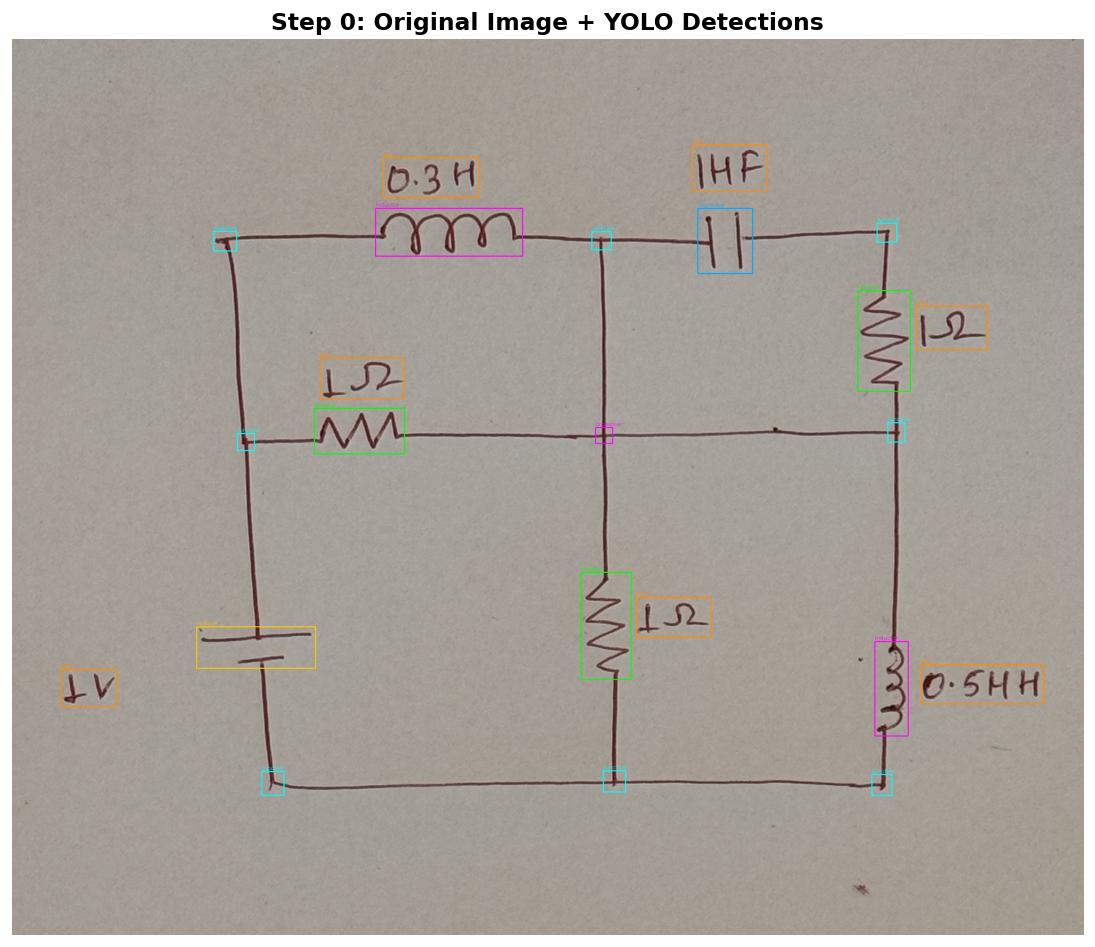

In [ ]:
IMG_PATH = "/Users/mac/Downloads/IMG_8924.jpg"

# Load image``
img_bgr = cv2.imread(IMG_PATH)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
IMG_H, IMG_W = img_gray.shape
print(f"Image size: {IMG_W} × {IMG_H}")

# Run YOLO detection
from test.yolo_detector import detect, parse_label_text, COMPONENT_NAMES

with open(IMG_PATH, "rb") as f:
    image_bytes = f.read()

label_text = detect(image_bytes, _decoded_bgr=img_bgr)
all_dets = parse_label_text(label_text, IMG_W, IMG_H)

print(f"\nYOLO found {len(all_dets)} detections:")
for d in all_dets:
    print(f"  {d['name']:25s}  conf={d['confidence']:.3f}  bbox={d['bbox']}")

# Show original with YOLO boxes
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
vis = img_bgr.copy()
colors = {
    "resistor": (0,255,0), "capacitor": (255,165,0), "inductor": (255,0,255),
    "diode": (0,255,255), "voltage": (0,200,255), "gnd": (128,128,128),
    "junction": (255,255,0), "crossover": (255,0,255), "text": (0,140,255),
    "terminal": (100,255,100), "switch": (200,200,0), "transistor": (255,0,128),
}
for d in all_dets:
    x1, y1, x2, y2 = d["bbox"]
    c = colors.get(d["name"], (255,255,255))
    cv2.rectangle(vis, (x1,y1), (x2,y2), c, 2)
    cv2.putText(vis, d["name"], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 1)
ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title("Step 0: Original Image + YOLO Detections", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## Step 1 — Binary Thresholding

Convert the grayscale image to pure black and white using a fixed threshold (default `110`).  
Pixels darker than the threshold → foreground (ink/wires), lighter → background (paper).

$$
\text{pixel}(x,y) = 
\begin{cases}
255 & \text{if } I(x,y) > T \\
0   & \text{otherwise}
\end{cases}
\quad\text{where } T = 110
$$

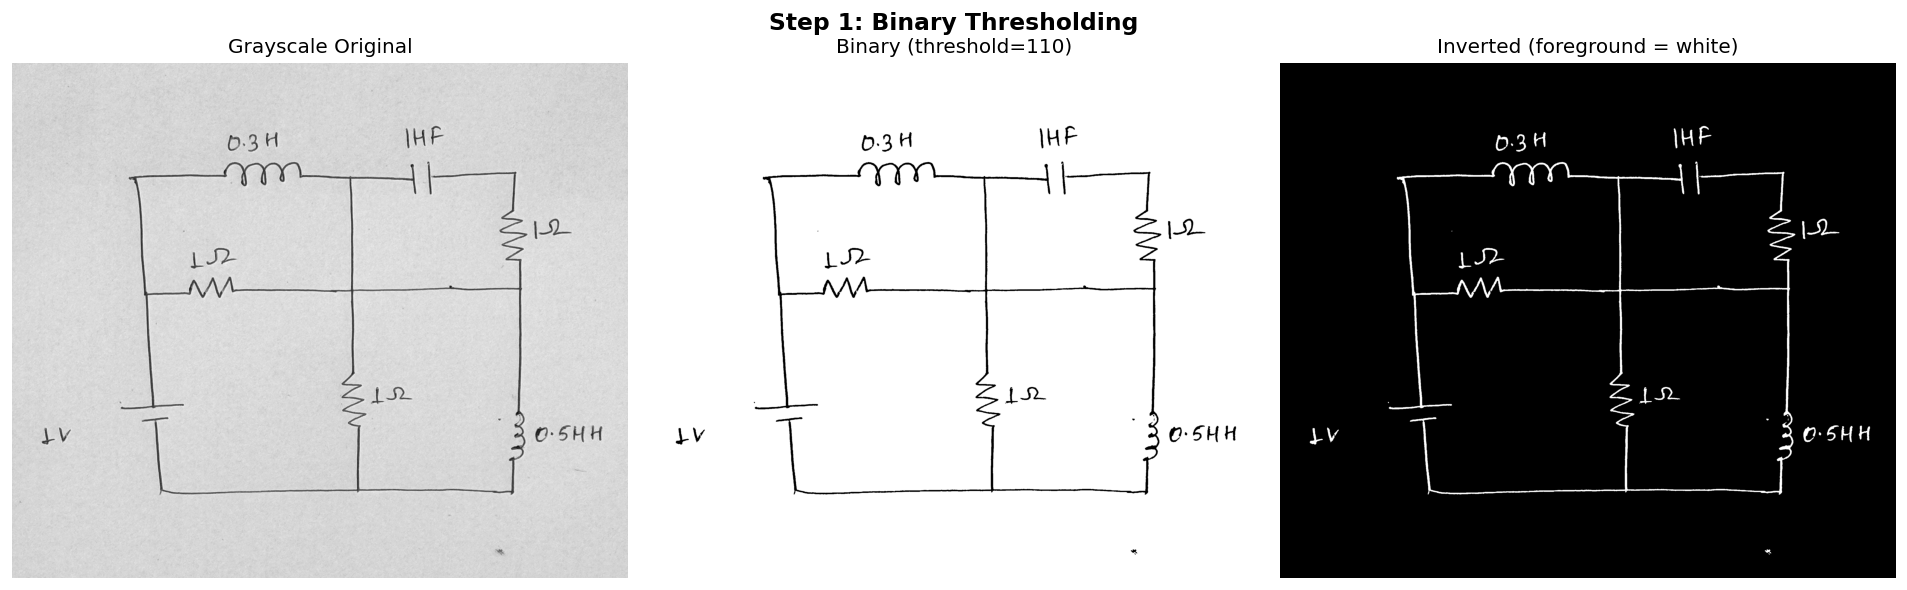

Foreground pixels: 132,698 / 7,003,480 (1.9%)


In [15]:
BINARY_THRESH = 110

# Median blur (kernel=1 → identity, but keeps the API consistent)
denoised = cv2.medianBlur(img_gray, 1)

# Binary threshold
_, binary = cv2.threshold(denoised, BINARY_THRESH, 255, cv2.THRESH_BINARY)

# Invert: foreground (ink) becomes white for skeletonize
inverted = cv2.bitwise_not(binary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Grayscale Original")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title(f"Binary (threshold={BINARY_THRESH})")
axes[2].imshow(inverted, cmap="gray")
axes[2].set_title("Inverted (foreground = white)")
for ax in axes: ax.axis("off")
fig.suptitle("Step 1: Binary Thresholding", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Foreground pixels: {np.count_nonzero(inverted):,} / {IMG_W*IMG_H:,} ({100*np.count_nonzero(inverted)/(IMG_W*IMG_H):.1f}%)")

## Step 2 — Morphological Skeletonization

Reduce all foreground regions to **1-pixel-wide** centerlines using Zhang–Suen thinning (`skimage.morphology.skeletonize`).  
This gives us the "wire skeleton" — the topological backbone of every line in the image.

Thick lines, component bodies, and text all get thinned to single-pixel paths.

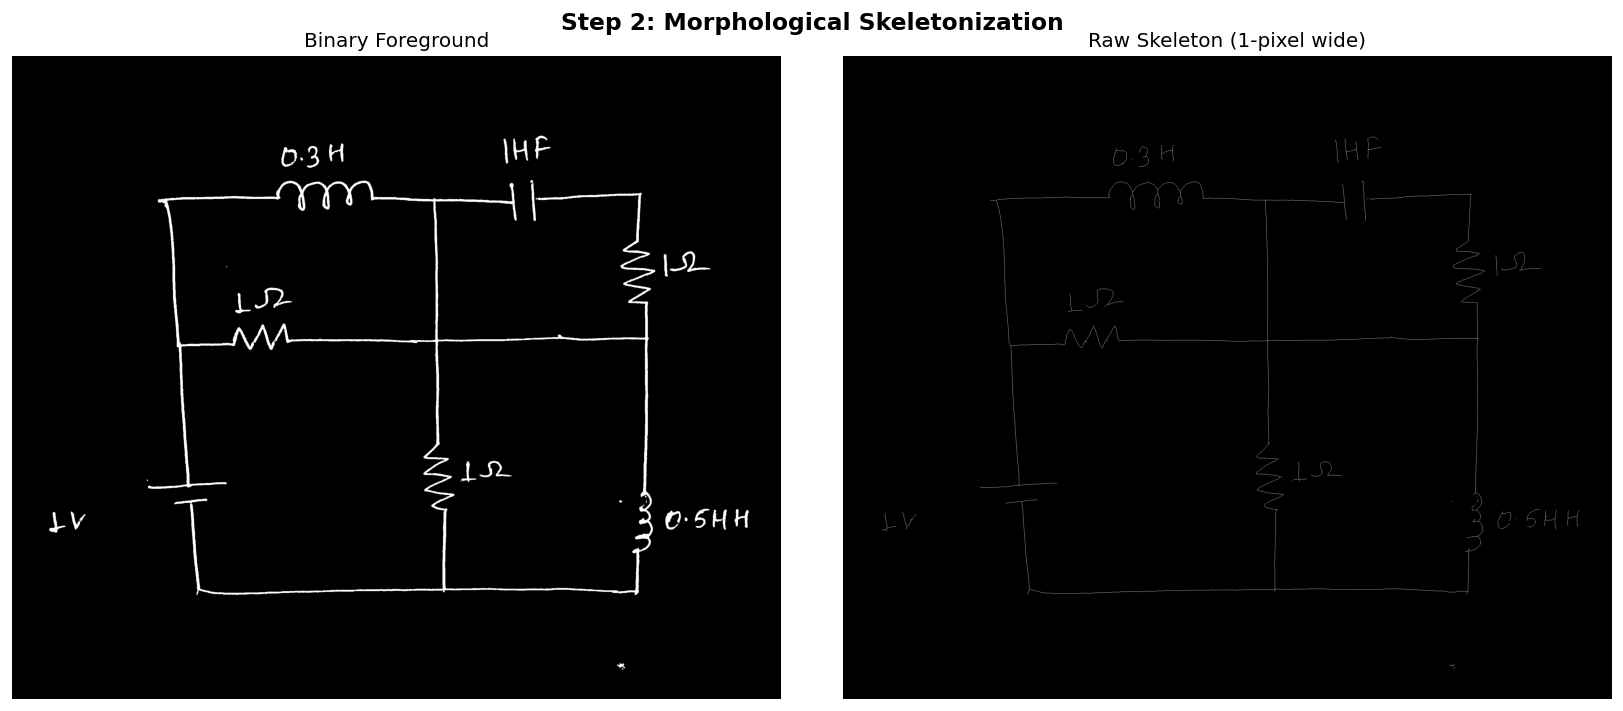

Skeleton pixels: 14,926 (reduced from 132,698 foreground pixels)
Thinning ratio: 8.9× reduction


In [16]:
# First skeletonization
skeleton_raw = skeletonize(inverted > 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(inverted, cmap="gray")
axes[0].set_title("Binary Foreground")
axes[1].imshow(skeleton_raw, cmap="gray")
axes[1].set_title("Raw Skeleton (1-pixel wide)")
for ax in axes: ax.axis("off")
fig.suptitle("Step 2: Morphological Skeletonization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

skel_pixels = np.count_nonzero(skeleton_raw)
print(f"Skeleton pixels: {skel_pixels:,} (reduced from {np.count_nonzero(inverted):,} foreground pixels)")
print(f"Thinning ratio: {np.count_nonzero(inverted)/max(skel_pixels,1):.1f}× reduction")

## Step 3 — Text Region Erasure

Text labels (class 11 from YOLO, e.g. "10kΩ", "5V") produce skeleton noise — spurious branches that look like wires. We blank out every text bounding box on the skeleton **before** building the wire graph.

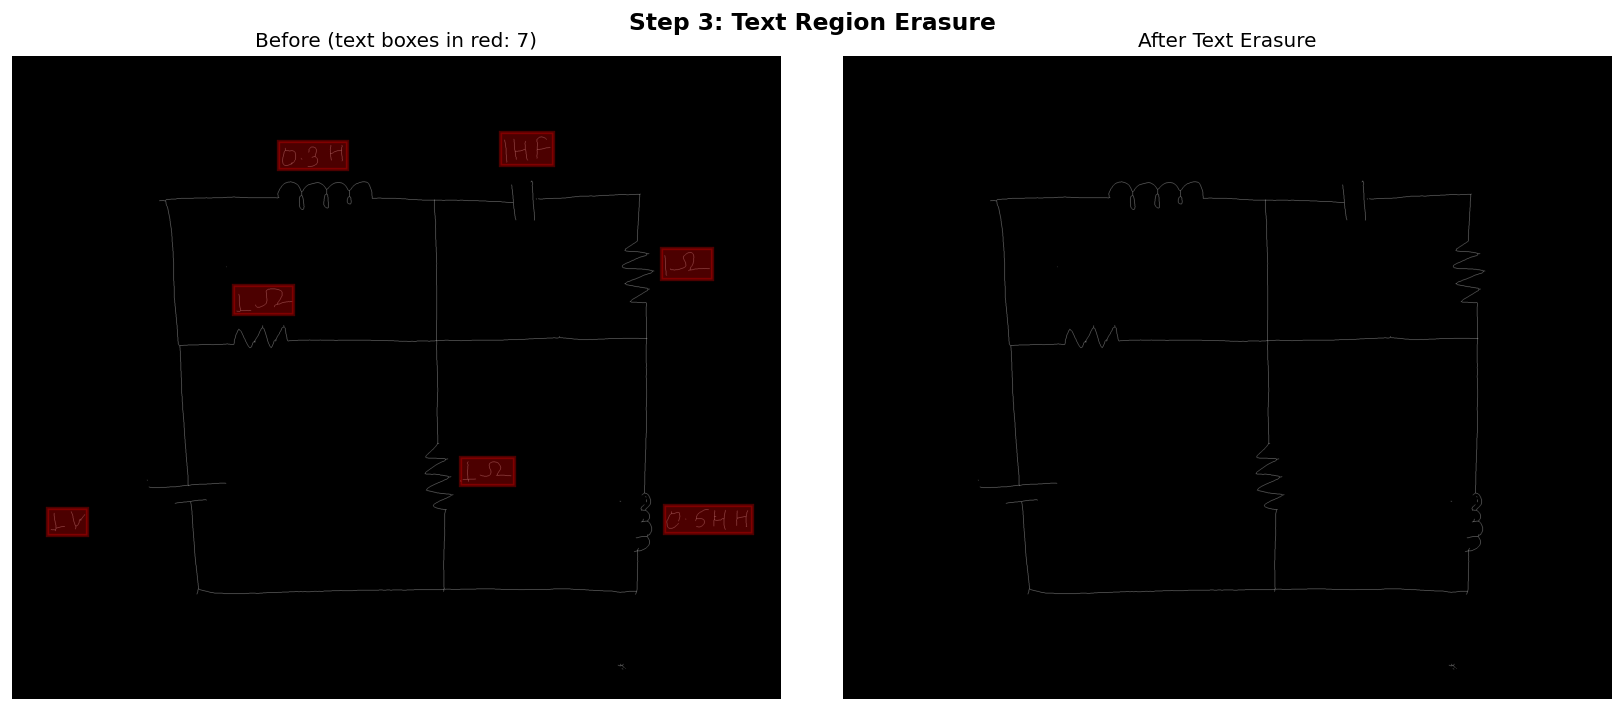

Erased 7 text regions, removed 2,887 skeleton pixels


In [17]:
# Parse YOLO detections into bbox format
yolo_dets = _parse_yolo_text(label_text)
detections_with_bbox = []
for d in yolo_dets:
    xyxy = _yolo_to_xyxy(d["xc"], d["yc"], d["w"], d["h"], IMG_W, IMG_H)
    detections_with_bbox.append({**d, "bbox_xyxy": xyxy})

# Erase text regions from skeleton
skeleton = skeleton_raw.copy()
text_boxes_erased = 0
for d in detections_with_bbox:
    if d["cls"] == 11:  # text class
        x1, y1, x2, y2 = d["bbox_xyxy"]
        skeleton[y1:y2, x1:x2] = False
        text_boxes_erased += 1

# Visualize: highlight erased regions in red
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before
axes[0].imshow(skeleton_raw, cmap="gray")
for d in detections_with_bbox:
    if d["cls"] == 11:
        x1, y1, x2, y2 = d["bbox_xyxy"]
        rect = plt.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=2, edgecolor="red", facecolor="red", alpha=0.3)
        axes[0].add_patch(rect)
axes[0].set_title(f"Before (text boxes in red: {text_boxes_erased})")

# After
axes[1].imshow(skeleton, cmap="gray")
axes[1].set_title("After Text Erasure")

for ax in axes: ax.axis("off")
fig.suptitle("Step 3: Text Region Erasure", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

erased = np.count_nonzero(skeleton_raw) - np.count_nonzero(skeleton)
print(f"Erased {text_boxes_erased} text regions, removed {erased:,} skeleton pixels")

## Step 4 — Dilation & Re-Skeletonization

Text erasure may break wires that passed through text boxes. A single pass of **3×3 morphological dilation** fills micro-gaps, then **re-skeletonization** restores the 1-pixel-wide skeleton.

This is the **final clean skeleton** used for all subsequent graph-building.

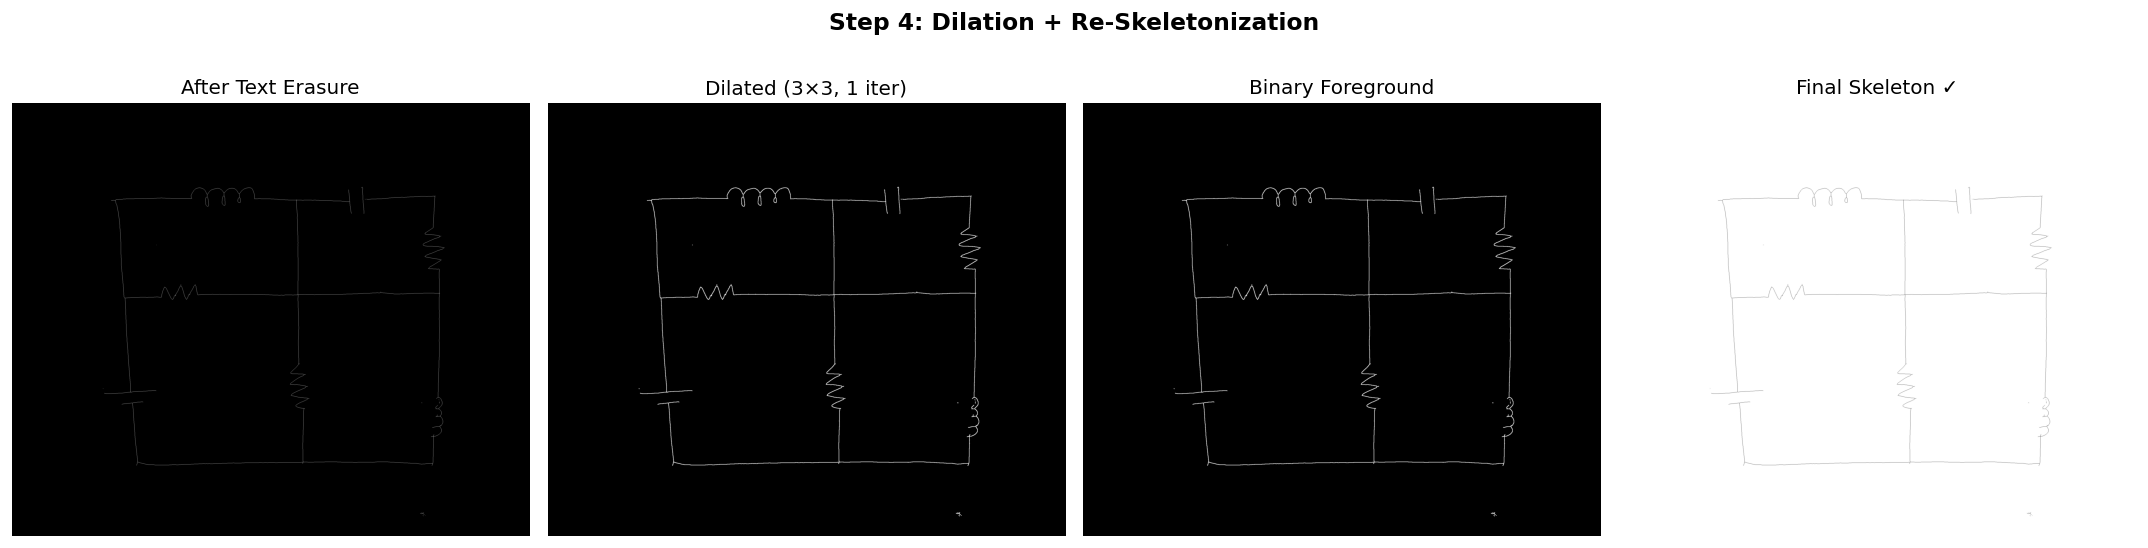

Final skeleton: 12,054 pixels


In [18]:
# Dilate to fill small gaps
img_u8 = skeleton.astype(np.uint8) * 255
kernel = np.ones((3, 3), np.uint8)
dilated = cv2.dilate(img_u8, kernel, iterations=1)

# Re-skeletonize
dilated_inv = cv2.bitwise_not(dilated)
binary_fg = (dilated_inv < 128).astype(np.uint8)
skel = skeletonize(binary_fg.astype(bool)).astype(np.uint8)
skel_u8 = img_as_ubyte(skel)

# Black-on-white for nice display
skel_display = np.ones_like(skel_u8) * 255
skel_display[skel_u8 > 0] = 0

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(skeleton.astype(np.uint8)*255, cmap="gray")
axes[0].set_title("After Text Erasure")
axes[1].imshow(dilated, cmap="gray")
axes[1].set_title("Dilated (3×3, 1 iter)")
axes[2].imshow(binary_fg*255, cmap="gray")
axes[2].set_title("Binary Foreground")
axes[3].imshow(skel_display, cmap="gray")
axes[3].set_title("Final Skeleton ✓")
for ax in axes: ax.axis("off")
fig.suptitle("Step 4: Dilation + Re-Skeletonization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Final skeleton: {np.count_nonzero(skel):,} pixels")

# This is the skeleton used for everything below
skel_img = skel

## Step 5 — Endpoint Detection

Two strategies are used depending on the YOLO class:

### Strategy A: Center-snap (classes 1, 6, 10 — crossover, junction, terminal)
Find the skeleton pixel **nearest to the bounding-box center**. These are wire meeting points — a single point.

### Strategy B: Border intersections (all other components)
Find where the **skeleton crosses the bbox perimeter**. A resistor with two leads produces two border hits → two endpoints. Nearby hits are merged (within 8px).

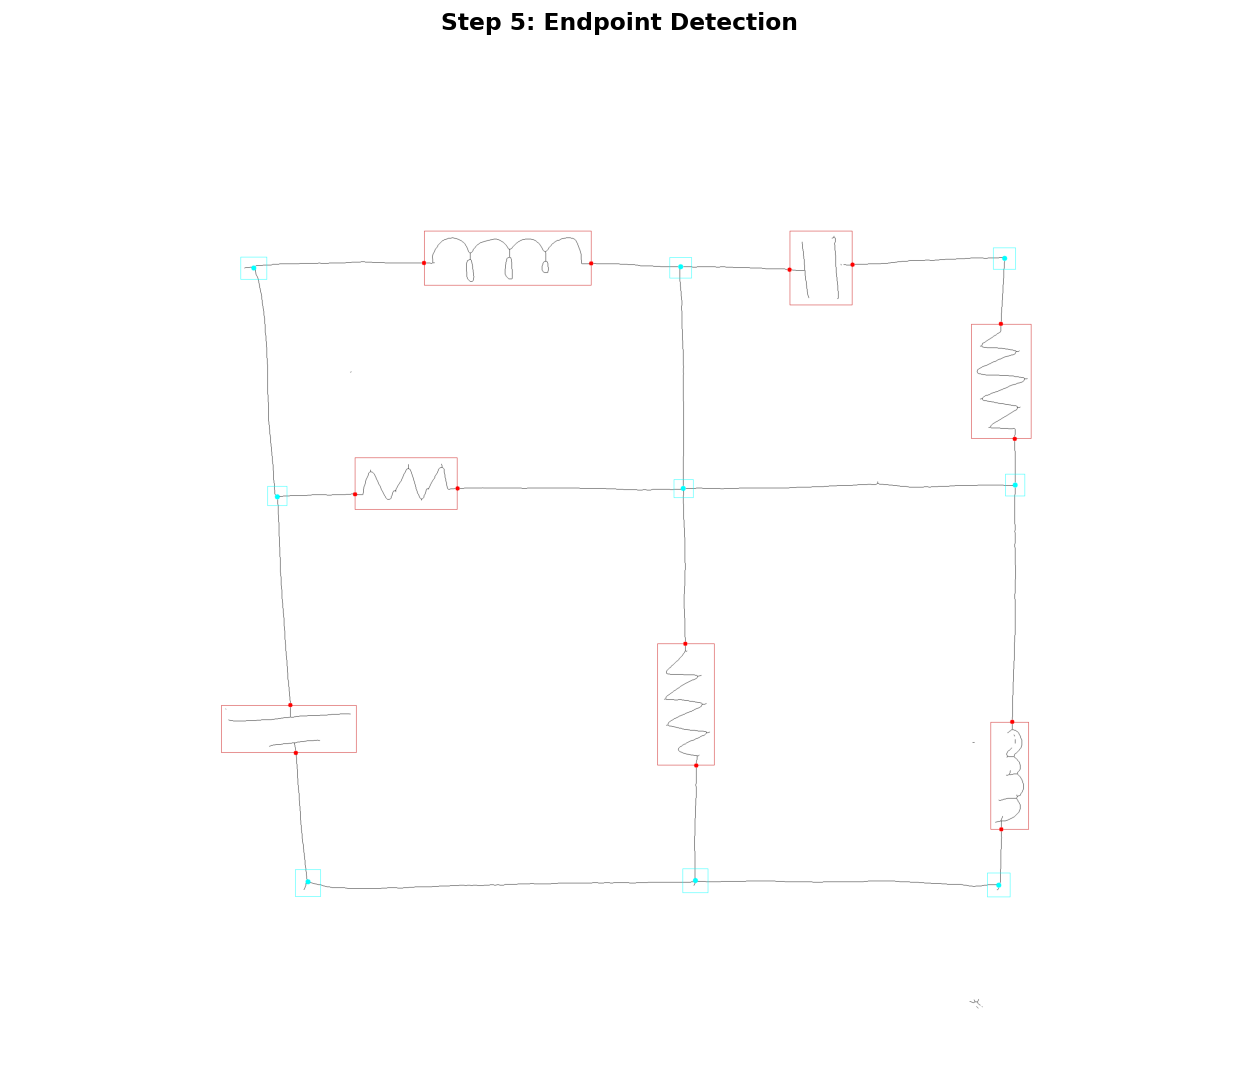

Center-snap endpoints (cyan): 9
Border-hit endpoints (red):   28
Total detections processed:   16

Methods used:
  inductor                   method=all_border_hits_cleaned         endpoints=2
  resistor                   method=all_border_hits_cleaned         endpoints=2
  voltage                    method=all_border_hits_cleaned         endpoints=2
  inductor                   method=all_border_hits_cleaned         endpoints=2
  resistor                   method=all_border_hits_cleaned         endpoints=2
  capacitor                  method=all_border_hits_cleaned         endpoints=2
  resistor                   method=all_border_hits_cleaned         endpoints=2
  junction                   method=cls1_center_snap                endpoints=1
  junction                   method=cls1_center_snap                endpoints=1
  junction                   method=cls1_center_snap                endpoints=1
  junction                   method=cls1_center_snap                endpoints=1
  junct

In [19]:
CLS1_MARGIN = 8
BORDER_TOL = 1

results = []
for d in detections_with_bbox:
    if d["cls"] == 11:  # skip text
        continue
    x1, y1, x2, y2 = d["bbox_xyxy"]
    if d["cls"] in (1, 6, 10):  # crossover, junction, terminal → center snap
        ep, method = _endpoint_for_class1_single(skel_img, x1, y1, x2, y2, margin=CLS1_MARGIN)
        results.append({
            "id": d["cls"], "conf": d["conf"],
            "bbox_xyxy": (x1, y1, x2, y2),
            "endpoint_xy": ep, "method": method,
        })
    else:  # border intersection strategy
        inter = _skeleton_intersections_with_bbox_border(skel_img, x1, y1, x2, y2, tol=BORDER_TOL)
        if len(inter) == 0:
            roi = skel_img[y1:y2+1, x1:x2+1]
            ys, xs = np.where(roi > 0)
            pts = [tuple(map(int, pt)) for pt in np.stack([x1+xs, y1+ys], axis=1)] if len(xs) > 0 else []
            method = "fallback_internal"
        else:
            pts, method = _get_all_border_intersections(skel_img, inter)
        results.append({
            "id": d["cls"], "conf": d["conf"],
            "bbox_xyxy": (x1, y1, x2, y2),
            "endpoints": pts, "method": method,
        })

# Visualize endpoints on skeleton
fig, ax = plt.subplots(1, 1, figsize=(12, 9))
vis = cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR)

center_snap_count = 0
border_hit_count = 0

for r in results:
    x1, y1, x2, y2 = r["bbox_xyxy"]
    name = COMPONENT_NAMES[r["id"]] if r["id"] < len(COMPONENT_NAMES) else f"cls_{r['id']}"
    
    if "endpoint_xy" in r and r["endpoint_xy"]:
        # Center-snap: CYAN circle
        cv2.circle(vis, r["endpoint_xy"], 6, (255, 255, 0), -1)
        cv2.rectangle(vis, (x1,y1), (x2,y2), (255, 255, 0), 1)
        center_snap_count += 1
    elif "endpoints" in r:
        # Border intersections: RED circles
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0, 0, 200), 1)
        for p in r["endpoints"]:
            cv2.circle(vis, tuple(p), 5, (0, 0, 255), -1)
            border_hit_count += len(r["endpoints"])

ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title("Step 5: Endpoint Detection", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Center-snap endpoints (cyan): {center_snap_count}")
print(f"Border-hit endpoints (red):   {border_hit_count}")
print(f"Total detections processed:   {len(results)}")
print(f"\nMethods used:")
for r in results:
    name = COMPONENT_NAMES[r["id"]] if r["id"] < len(COMPONENT_NAMES) else f"cls_{r['id']}"
    n_eps = 1 if "endpoint_xy" in r else len(r.get("endpoints", []))
    print(f"  {name:25s}  method={r['method']:30s}  endpoints={n_eps}")

## Step 6 — Global Endpoint Merging

Endpoints from different detections that are physically the same point (e.g., a junction's center-snap and a resistor's border-hit landing on the same wire) are merged if they fall within `global_merge_dist = 5px`.

Each unique merged point becomes a **graph node**.

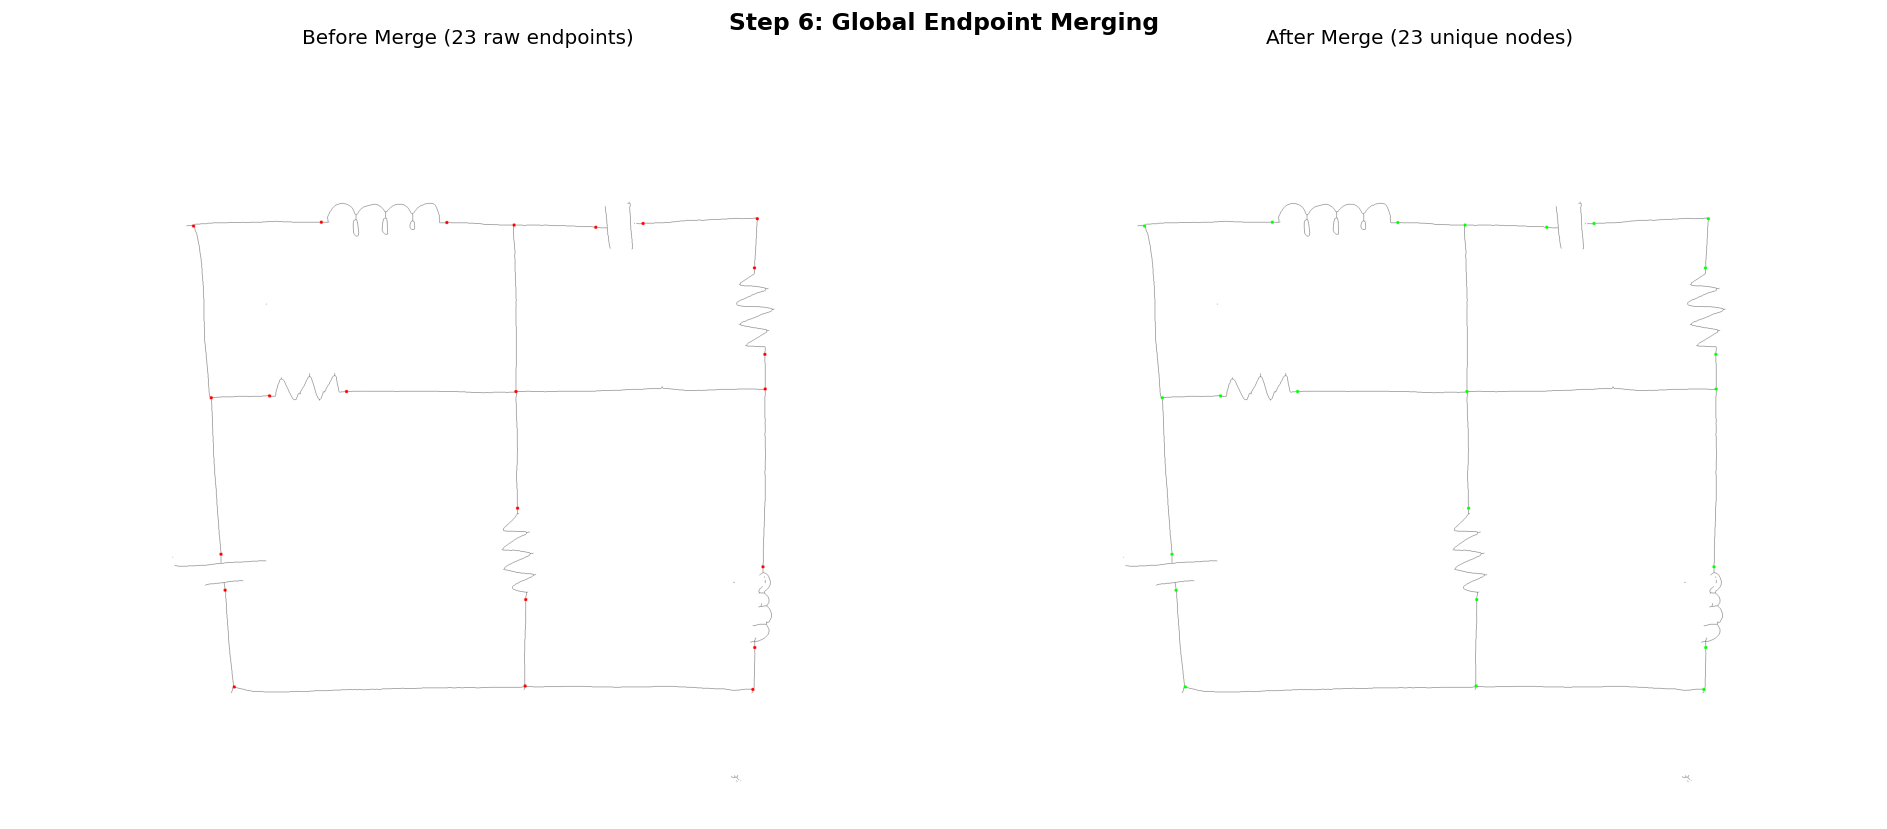

Raw endpoints:  23
After merging:  23 nodes  (0 merged away)
Merge distance: 5.0 px


In [20]:
GLOBAL_MERGE_DIST = 5.0

# Collect all raw endpoints before merging
raw_pts = []
for r in results:
    if "endpoint_xy" in r and r["endpoint_xy"] is not None:
        raw_pts.append(r["endpoint_xy"])
    if "endpoints" in r and r["endpoints"]:
        for ep in r["endpoints"]:
            if ep is not None:
                raw_pts.append(tuple(map(int, ep)))

# Merge
all_nodes = _extract_all_endpoints(results, global_merge_dist=GLOBAL_MERGE_DIST)

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (pts, title, color) in enumerate([
    (raw_pts, f"Before Merge ({len(raw_pts)} raw endpoints)", "red"),
    (all_nodes, f"After Merge ({len(all_nodes)} unique nodes)", "lime"),
]):
    vis = cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR)
    for p in pts:
        cv2.circle(vis, tuple(map(int, p)), 5, 
                   (0,0,255) if color=="red" else (0,255,0), -1)
    axes[idx].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(title)
    axes[idx].axis("off")

fig.suptitle("Step 6: Global Endpoint Merging", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

merged_away = len(raw_pts) - len(all_nodes)
print(f"Raw endpoints:  {len(raw_pts)}")
print(f"After merging:  {len(all_nodes)} nodes  ({merged_away} merged away)")
print(f"Merge distance: {GLOBAL_MERGE_DIST} px")

## Step 7 — Multi-Head BFS Adjacency Graph

The core algorithm: determine which nodes are **connected by wires**.

For each node:
1. Stamp a **disk of radius 25px** onto a node-ID map
2. Seed BFS from skeleton pixels just outside the disk
3. Walk along the skeleton (8-connectivity) until another node's disk is reached
4. Record that node as a neighbor

This produces the **raw adjacency graph** — which nodes can reach each other along skeleton paths.

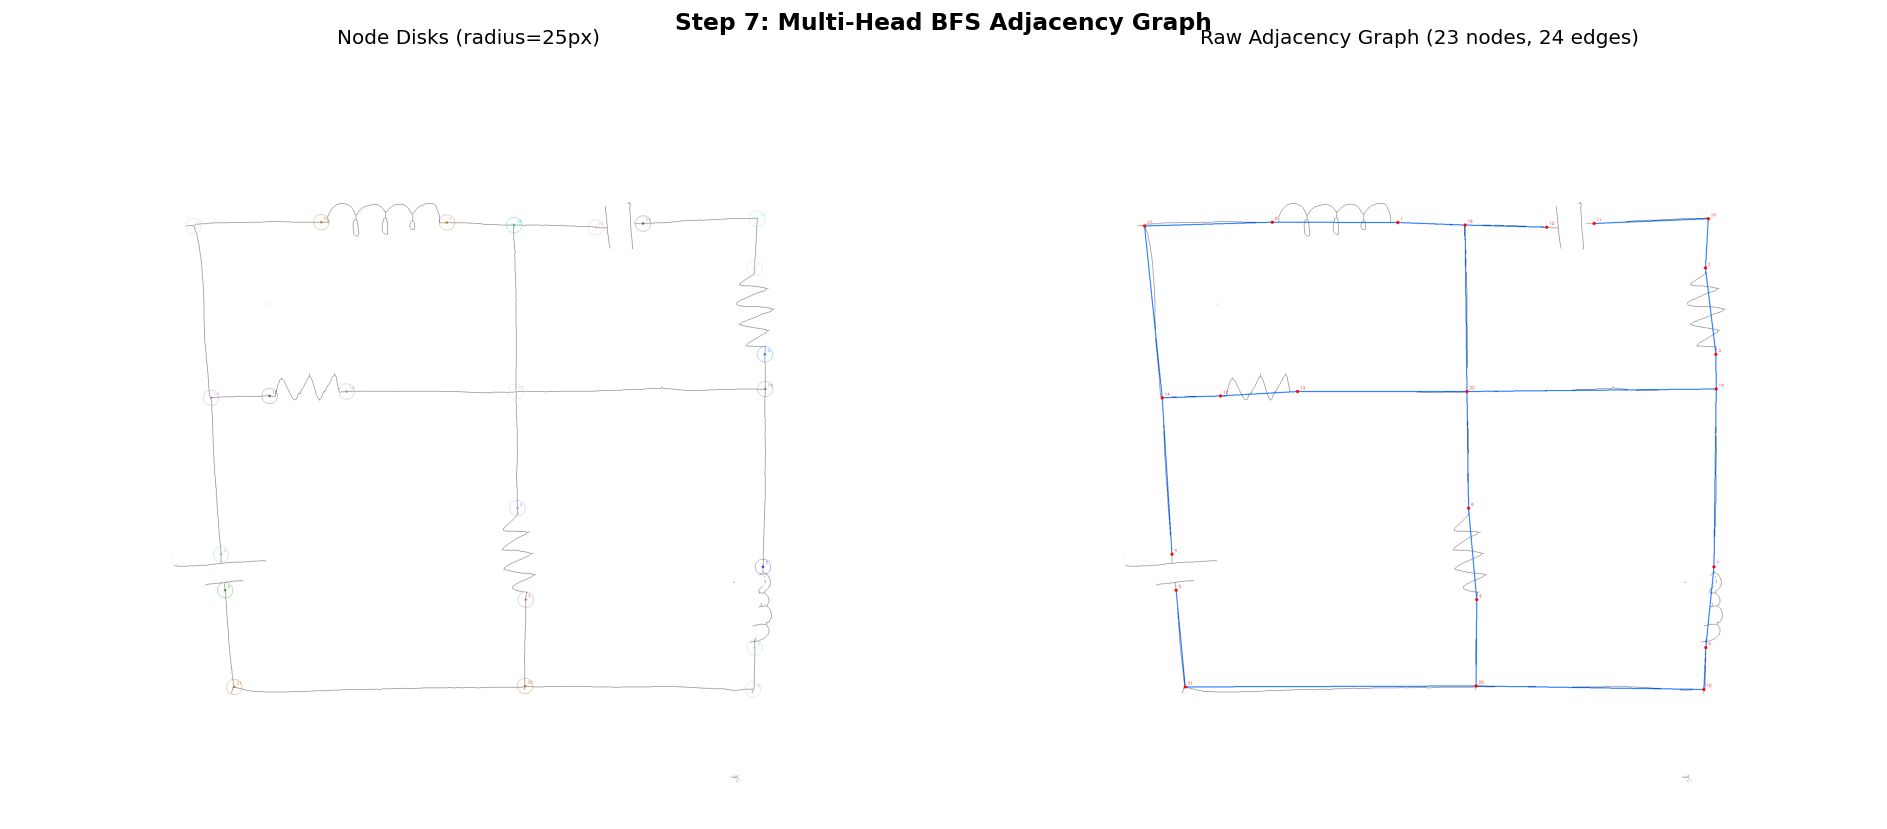

Adjacency list:
  Node  0 ( 980, 533) → [np.int32(1), np.int32(17)]
  Node  1 (1378, 534) → [0, np.int32(18)]
  Node  2 (2353, 678) → [np.int32(3), np.int32(19)]
  Node  3 (2386, 952) → [2, np.int32(16)]
  Node  4 ( 662,1586) → [np.int32(14)]
  Node  5 ( 675,1700) → [np.int32(21)]
  Node  6 (2354,1882) → [np.int32(7), np.int32(15)]
  Node  7 (2380,1626) → [6, np.int32(16)]
  Node  8 (1602,1440) → [np.int32(9), np.int32(22)]
  Node  9 (1628,1730) → [8, np.int32(20)]
  Node 10 (1850, 549) → [np.int32(18)]
  Node 11 (2000, 537) → [np.int32(19)]
  Node 12 ( 816,1084) → [np.int32(13), np.int32(14)]
  Node 13 (1060,1070) → [12, np.int32(22)]
  Node 14 ( 631,1090) → [4, 12, np.int32(17)]
  Node 15 (2348,2015) → [6, np.int32(20)]
  Node 16 (2387,1062) → [3, 7, np.int32(22)]
  Node 17 ( 575, 545) → [0, 14]
  Node 18 (1591, 542) → [1, 10, np.int32(22)]
  Node 19 (2362, 522) → [2, 11]
  Node 20 (1626,2004) → [9, 15, np.int32(21)]
  Node 21 ( 704,2007) → [5, 20]
  Node 22 (1597,1070) → [8, 13, 16,

In [21]:
NODE_RADIUS = 25

# Build adjacency graph
adjacency = _build_adjacency(skel_img, all_nodes, radius=NODE_RADIUS)

# Visualize the node ID map (each disk colored differently)
node_id_map = _build_node_id_map(skel_img, all_nodes, NODE_RADIUS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Node disks overlaid on skeleton
vis1 = cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR)
cmap = plt.cm.tab20(np.linspace(0, 1, max(len(all_nodes), 1)))
for i, (nx, ny) in enumerate(all_nodes):
    color = tuple(int(c*255) for c in cmap[i % 20][:3])
    cv2.circle(vis1, (nx, ny), NODE_RADIUS, color, 1)
    cv2.circle(vis1, (nx, ny), 4, color, -1)
    cv2.putText(vis1, str(i), (nx+8, ny-8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
axes[0].imshow(cv2.cvtColor(vis1, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Node Disks (radius={NODE_RADIUS}px)")

# Right: Adjacency graph drawn as edges
vis2 = cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR)
drawn = set()
edge_count = 0
for i, nbrs in adjacency.items():
    x1, y1 = all_nodes[i]
    for j in nbrs:
        edge = tuple(sorted([i, j]))
        if edge in drawn:
            continue
        drawn.add(edge)
        x2, y2 = all_nodes[j]
        cv2.line(vis2, (x1, y1), (x2, y2), (255, 100, 0), 2)
        edge_count += 1
for i, (nx, ny) in enumerate(all_nodes):
    cv2.circle(vis2, (nx, ny), 5, (0, 0, 255), -1)
    cv2.putText(vis2, str(i), (nx+8, ny-8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)
axes[1].imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Raw Adjacency Graph ({len(all_nodes)} nodes, {edge_count} edges)")

for ax in axes: ax.axis("off")
fig.suptitle("Step 7: Multi-Head BFS Adjacency Graph", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print adjacency list
print("Adjacency list:")
for i in sorted(adjacency.keys()):
    nbrs = sorted(adjacency[i])
    print(f"  Node {i:2d} ({all_nodes[i][0]:4d},{all_nodes[i][1]:4d}) → {nbrs}")

## Step 8 — Remove Internal Component Connections

Multi-terminal components (e.g., a resistor with two leads detected) have both endpoints as graph nodes. The BFS finds a path *through the component body* connecting them — a false edge. We remove these internal connections.

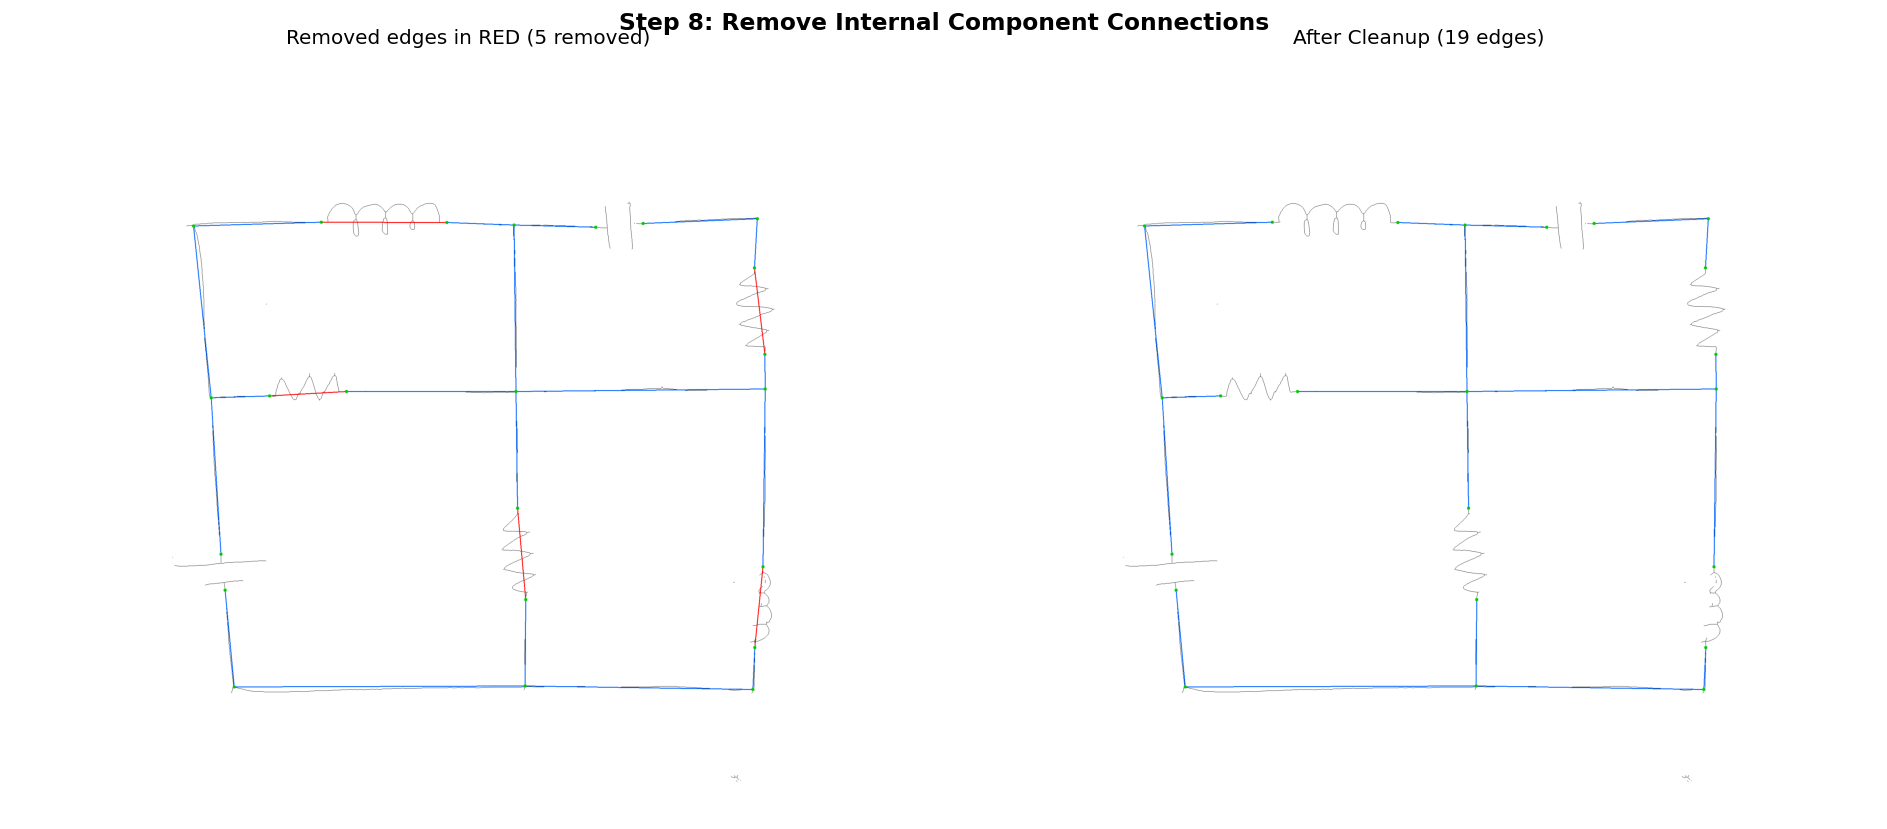

Edges before: 24 → after: 19 (5 internal edges removed)
  Removed: node 0 ↔ node 1 (through inductor)
  Removed: node 2 ↔ node 3 (through resistor)
  Removed: node 6 ↔ node 7 (through inductor)
  Removed: node 8 ↔ node 9 (through resistor)
  Removed: node 12 ↔ node 13 (through resistor)


In [22]:
FIND_NODE_DIST = 5

# Count edges before
edges_before = sum(len(v) for v in adjacency.values()) // 2

# Remove internal component connections
removed_edges = []
for r in results:
    if "endpoints" in r and len(r.get("endpoints", [])) >= 2:
        for (p1, p2) in combinations(r["endpoints"], 2):
            i1 = _find_node_index(p1, all_nodes, FIND_NODE_DIST)
            i2 = _find_node_index(p2, all_nodes, FIND_NODE_DIST)
            if i1 != -1 and i2 != -1 and i2 in adjacency.get(i1, set()):
                adjacency[i1].discard(i2)
                adjacency[i2].discard(i1)
                name = COMPONENT_NAMES[r["id"]] if r["id"] < len(COMPONENT_NAMES) else f"cls_{r['id']}"
                removed_edges.append((i1, i2, name))

edges_after = sum(len(v) for v in adjacency.values()) // 2

# Visualize the removed edges
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Before (show removed edges in red dashed)
vis1 = cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR)
drawn = set()
for i, nbrs in adjacency.items():
    for j in nbrs:
        edge = tuple(sorted([i, j]))
        if edge in drawn: continue
        drawn.add(edge)
        cv2.line(vis1, all_nodes[i], all_nodes[j], (255, 100, 0), 2)
for i1, i2, name in removed_edges:
    cv2.line(vis1, all_nodes[i1], all_nodes[i2], (0, 0, 255), 2)  # red = removed
for i, (nx, ny) in enumerate(all_nodes):
    cv2.circle(vis1, (nx, ny), 5, (0, 200, 0), -1)
axes[0].imshow(cv2.cvtColor(vis1, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Removed edges in RED ({len(removed_edges)} removed)")

# After
vis2 = cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR)
drawn = set()
for i, nbrs in adjacency.items():
    for j in nbrs:
        edge = tuple(sorted([i, j]))
        if edge in drawn: continue
        drawn.add(edge)
        cv2.line(vis2, all_nodes[i], all_nodes[j], (255, 100, 0), 2)
for i, (nx, ny) in enumerate(all_nodes):
    cv2.circle(vis2, (nx, ny), 5, (0, 200, 0), -1)
axes[1].imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"After Cleanup ({edges_after} edges)")

for ax in axes: ax.axis("off")
fig.suptitle("Step 8: Remove Internal Component Connections", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Edges before: {edges_before} → after: {edges_after} ({len(removed_edges)} internal edges removed)")
for i1, i2, name in removed_edges:
    print(f"  Removed: node {i1} ↔ node {i2} (through {name})")

## Step 9 — Crossover Dissolution (Dot-Product Pairing)

**The key insight:** A crossover (class 1) is where two wires cross without connecting. The skeleton produces a 4-way junction — but electrically, it should be two separate wires passing over each other.

**Algorithm:**
1. Find crossover nodes with exactly 4 neighbors
2. Compute unit vectors from the crossover to each neighbor
3. Test all 3 possible pairings of 4 neighbors into 2 pairs
4. The best pairing has the most **antiparallel** vectors (dot product ≈ −1)
5. If both pairs have dot product < −0.7, dissolve the crossover: remove the central node and wire the paired neighbors directly

$$\text{score} = \vec{v}_A \cdot \vec{v}_B + \vec{v}_C \cdot \vec{v}_D \quad \text{(minimize → most opposite)}$$

═══ Crossover at node 22 ((1597, 1070)) ═══
  4 neighbors: [8, 16, 18, 13]
  Pairing (8,16)+(18,13): dot1=0.003  dot2=0.011  score=0.015 ← BEST
  Pairing (8,18)+(16,13): dot1=-1.000  dot2=-1.000  score=-2.000 ← BEST
  Pairing (8,13)+(16,18): dot1=-0.014  dot2=-0.001  score=-0.015
  → Wire 8↔18 and 16↔13 (node 22 dissolved)



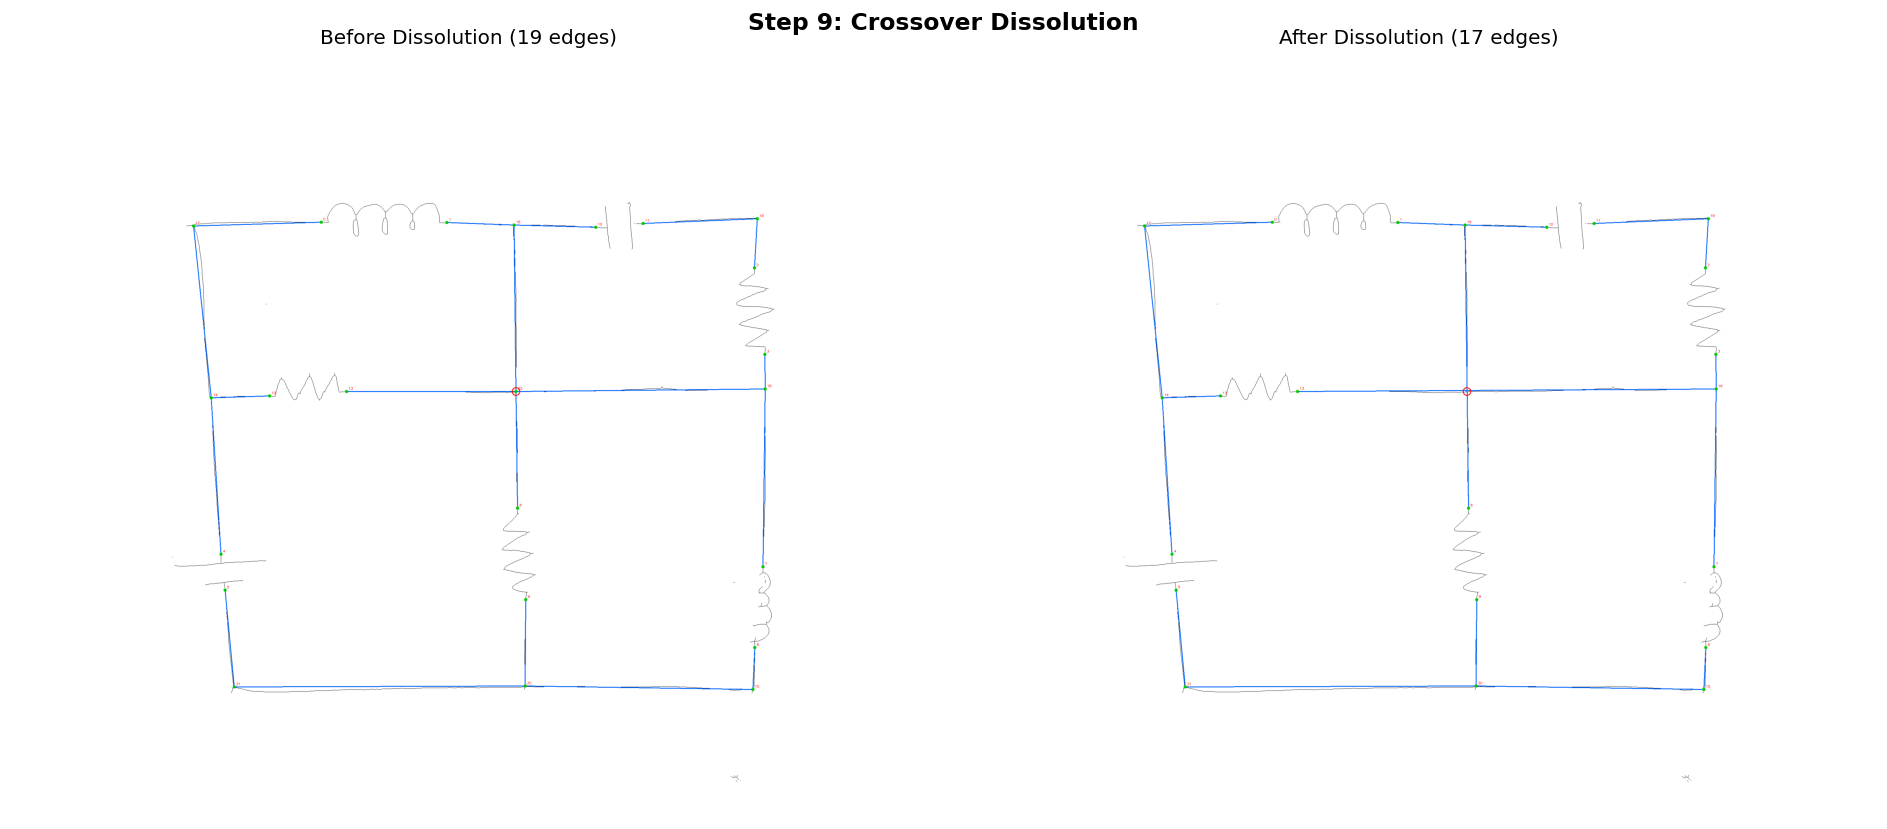


Dissolved 1 crossover node(s)
Connected components: 5


In [23]:
# Snapshot adjacency before dissolution for comparison
adj_before = {k: set(v) for k, v in adjacency.items()}
edges_before_dissolve = sum(len(v) for v in adj_before.values()) // 2

# Identify crossover nodes and show the dot-product analysis
crossover_info = []
for r in results:
    if r["id"] == 1 and "endpoint_xy" in r and r["endpoint_xy"] is not None:
        idx = _find_node_index(r["endpoint_xy"], all_nodes, FIND_NODE_DIST)
        if idx != -1:
            neighbors = list(adj_before.get(idx, set()))
            if len(neighbors) == 4:
                ax_, ay = all_nodes[idx]
                vecs = {}
                for n_idx in neighbors:
                    nx, ny = all_nodes[n_idx]
                    v = _normalized_vector(ax_, ay, nx, ny)
                    if v: vecs[n_idx] = v
                if len(vecs) == 4:
                    crossover_info.append({
                        "node": idx, "neighbors": neighbors, "vecs": vecs,
                        "pos": all_nodes[idx]
                    })

# Print dot-product analysis for each crossover
for ci in crossover_info:
    print(f"═══ Crossover at node {ci['node']} ({ci['pos']}) ═══")
    print(f"  4 neighbors: {ci['neighbors']}")
    b, c, d, e = ci['neighbors']
    pairings = [((b,c),(d,e)), ((b,d),(c,e)), ((b,e),(c,d))]
    best_score = float("inf")
    best_pairing = None
    for (p1,p2),(p3,p4) in pairings:
        dot1 = _dot(ci['vecs'][p1], ci['vecs'][p2])
        dot2 = _dot(ci['vecs'][p3], ci['vecs'][p4])
        score = dot1 + dot2
        winner = " ← BEST" if score < best_score else ""
        if score < best_score:
            best_score = score
            best_pairing = ((p1,p2),(p3,p4))
        print(f"  Pairing ({p1},{p2})+({p3},{p4}): dot1={dot1:.3f}  dot2={dot2:.3f}  score={score:.3f}{winner}")
    (pa,pb),(pc,pd) = best_pairing
    print(f"  → Wire {pa}↔{pb} and {pc}↔{pd} (node {ci['node']} dissolved)")
    print()

# Now actually dissolve
_dissolve_crossovers(results, all_nodes, adjacency, FIND_NODE_DIST)
edges_after_dissolve = sum(len(v) for v in adjacency.values()) // 2

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx_ax, (adj, title) in enumerate([
    (adj_before, f"Before Dissolution ({edges_before_dissolve} edges)"),
    (adjacency, f"After Dissolution ({edges_after_dissolve} edges)"),
]):
    vis = cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR)
    drawn = set()
    for i, nbrs in adj.items():
        for j in nbrs:
            edge = tuple(sorted([i, j]))
            if edge in drawn: continue
            drawn.add(edge)
            cv2.line(vis, all_nodes[i], all_nodes[j], (255, 100, 0), 2)
    for i in adj:
        cv2.circle(vis, all_nodes[i], 5, (0, 200, 0), -1)
        cv2.putText(vis, str(i), (all_nodes[i][0]+6, all_nodes[i][1]-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,0,255), 1)
    # Highlight crossover positions
    for ci in crossover_info:
        cv2.circle(vis, ci["pos"], 12, (0, 0, 255), 2)
    axes[idx_ax].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[idx_ax].set_title(title)
    axes[idx_ax].axis("off")

fig.suptitle("Step 9: Crossover Dissolution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

dissolved = len(crossover_info)
print(f"\nDissolved {dissolved} crossover node(s)")
print(f"Connected components: {_count_components(adjacency)}")

## Step 10 — Final Circuit Graph & Component-Node Mapping

With all transformations complete, we build the final data structures:

| Output | Description |
|--------|-------------|
| **Node-Component Map** | Which nodes belong to which component |
| **Adjacency List** | Which nodes are connected by wires |
| **Netlist** | Each component's type, value, and terminal nodes |

This is the representation that gets converted to CircuitJS `.circuitjs.txt` format.

═══  FINAL NETLIST  ═══

Total nodes:       23
Total edges:       17
Connected nets:    5
Components found:  7

─── Component─Node Mapping ───
  inductor      conf=0.93  → unmapped
  resistor      conf=0.92  → unmapped
  voltage       conf=0.89  → unmapped
  inductor      conf=0.89  → unmapped
  resistor      conf=0.89  → unmapped
  capacitor     conf=0.89  → unmapped
  resistor      conf=0.87  → unmapped
  junction      conf=0.82  → node 14
  junction      conf=0.76  → node 15
  junction      conf=0.76  → node 16
  junction      conf=0.76  → node 17
  junction      conf=0.76  → node 18
  junction      conf=0.72  → node 19
  junction      conf=0.71  → node 20
  junction      conf=0.69  → node 21
  crossover     conf=0.50  → node 22


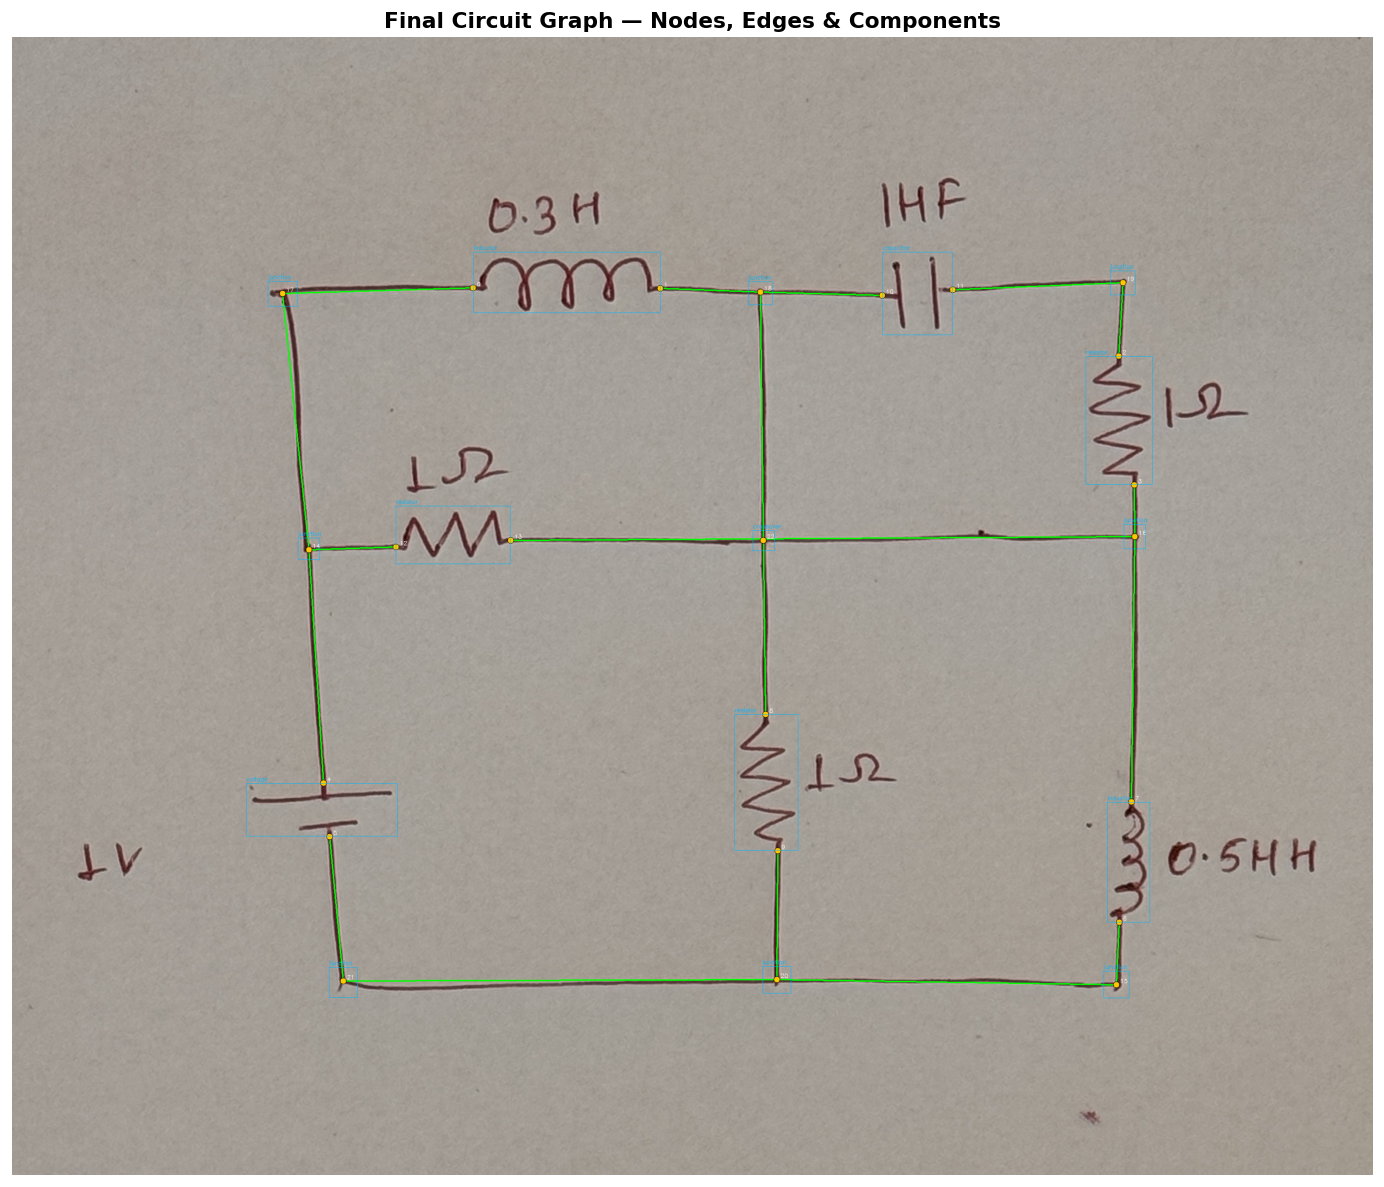

In [24]:
# Build the node→component map
node_comp_map = _build_node_component_map(results, all_nodes, adjacency, FIND_NODE_DIST)
comp_count = _count_components(adjacency)

# Print netlist summary
print("═══  FINAL NETLIST  ═══\n")
print(f"Total nodes:       {len(all_nodes)}")
print(f"Total edges:       {sum(len(v) for v in adjacency.values()) // 2}")
print(f"Connected nets:    {comp_count}")
print(f"Components found:  {len([r for r in results if r['id'] not in (1,6,11)])}\n")  # skip crossover, junction, text

print("─── Component─Node Mapping ───")
for r in results:
    cid = r["id"]
    cname = COMPONENT_NAMES[cid] if cid < len(COMPONENT_NAMES) else f"cls{cid}"
    if cid == 11:   # skip text
        continue
    ep = r.get("endpoint_xy")
    if ep:
        nidx = _find_node_index(ep, all_nodes, FIND_NODE_DIST)
        mapped = f"node {nidx}" if nidx != -1 else "unmapped"
    else:
        mapped = "unmapped"
    eps = r.get("endpoint_xys", [])
    if eps:
        idxs = [_find_node_index(p, all_nodes, FIND_NODE_DIST) for p in eps]
        mapped = f"nodes {idxs}"
    conf = r.get("conf", 0)
    print(f"  {cname:12s}  conf={conf:.2f}  → {mapped}")

# Final graph visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
vis = img_bgr.copy()

# Draw edges
drawn = set()
for i, nbrs in adjacency.items():
    for j in nbrs:
        edge = tuple(sorted([i, j]))
        if edge in drawn: continue
        drawn.add(edge)
        cv2.line(vis, all_nodes[i], all_nodes[j], (0, 255, 0), 2)

# Draw nodes
for i, (nx, ny) in enumerate(all_nodes):
    # Color by whether it belongs to a component
    color = (0, 200, 255) if i in node_comp_map else (200, 200, 200)
    cv2.circle(vis, (nx, ny), 7, color, -1)
    cv2.circle(vis, (nx, ny), 7, (0, 0, 0), 1)
    cv2.putText(vis, str(i), (nx + 8, ny - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

# Draw component bounding boxes
for det in detections_with_bbox:
    cid = det["cls"]
    cname = COMPONENT_NAMES[cid] if cid < len(COMPONENT_NAMES) else f"cls{cid}"
    if cid == 11: continue
    x1, y1, x2, y2 = det["bbox_xyxy"]
    color_box = (255, 180, 0)
    cv2.rectangle(vis, (x1, y1), (x2, y2), color_box, 1)
    cv2.putText(vis, cname, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color_box, 1)

ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title("Final Circuit Graph — Nodes, Edges & Components", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()

plt.show()

## Step 11 — Pipeline Summary

A side-by-side montage comparing key stages of the algorithm, from raw input to final graph.

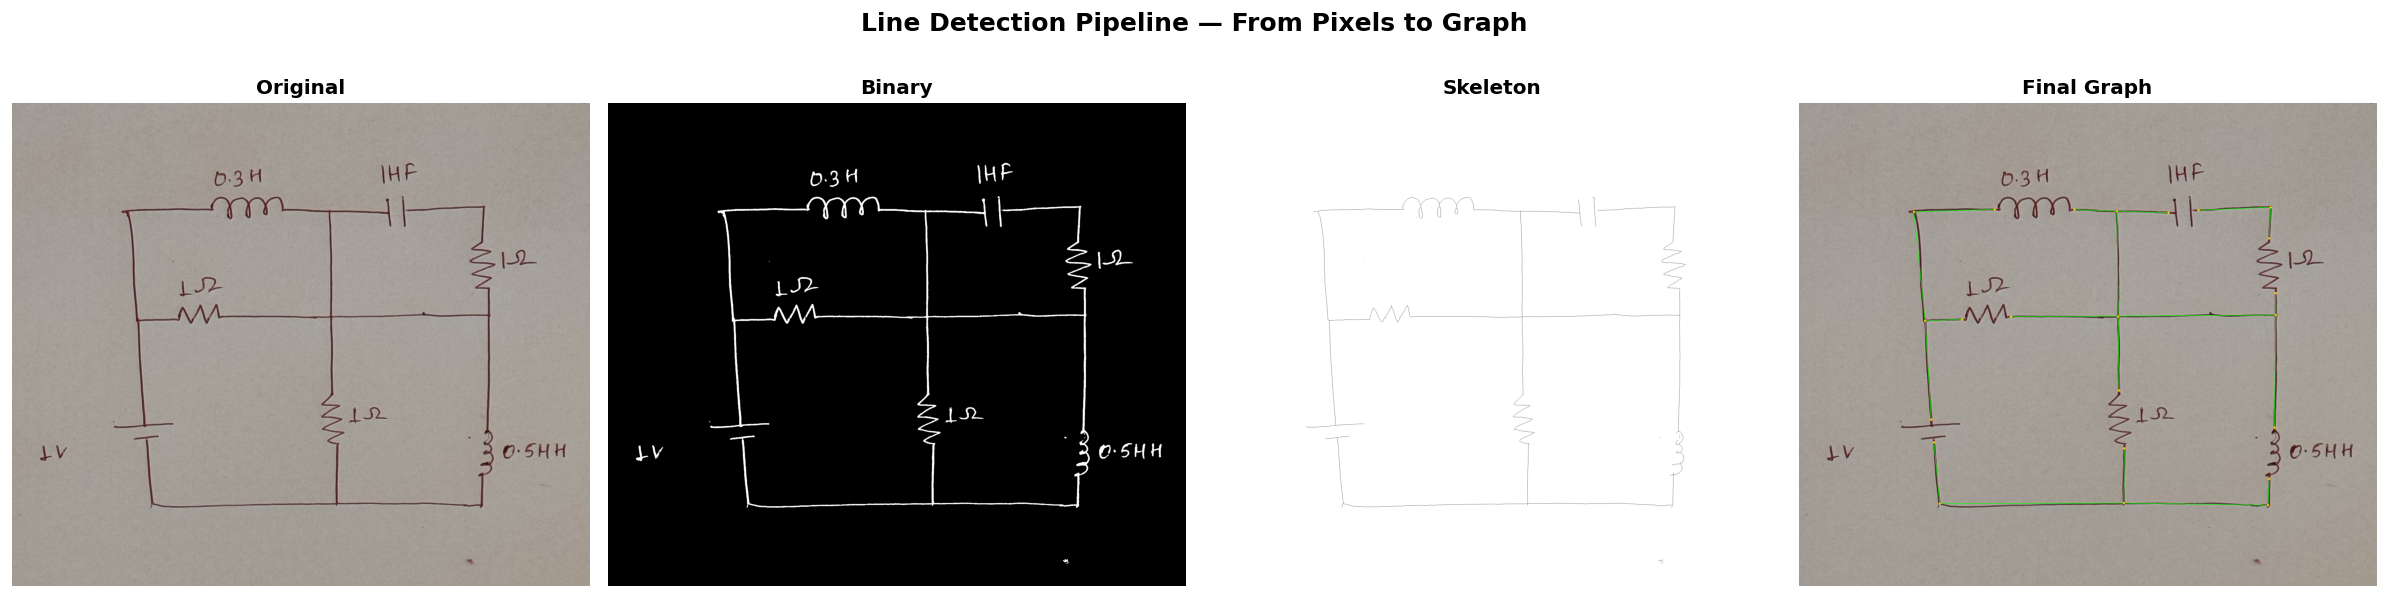

✓ Pipeline complete!


In [25]:
# Build summary montage
stages = {
    "Original": img_bgr,
    "Binary": cv2.cvtColor(cv2.threshold(img_gray, BINARY_THRESH, 255, cv2.THRESH_BINARY_INV)[1], cv2.COLOR_GRAY2BGR),
    "Skeleton": cv2.cvtColor(skel_display, cv2.COLOR_GRAY2BGR),
}

# Build final graph overlay
final_overlay = img_bgr.copy()
drawn_s = set()
for i, nbrs in adjacency.items():
    for j in nbrs:
        edge = tuple(sorted([i, j]))
        if edge in drawn_s: continue
        drawn_s.add(edge)
        cv2.line(final_overlay, all_nodes[i], all_nodes[j], (0, 255, 0), 2)
for i, (nx, ny) in enumerate(all_nodes):
    cv2.circle(final_overlay, (nx, ny), 6, (0, 200, 255), -1)
stages["Final Graph"] = final_overlay

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, img) in zip(axes, stages.items()):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.axis("off")
fig.suptitle("Line Detection Pipeline — From Pixels to Graph", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("✓ Pipeline complete!")